# 04 - Optimización de Hiperparámetros
GridSearchCV y RandomizedSearchCV para optimizar modelos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings
import time
warnings.filterwarnings('ignore')

# Agregar ruta de src al path
sys.path.insert(0, r'C:\Users\Arturo\Desktop\Prueba1\src')

# Importar módulos personalizados
from prueba.data_preprocessing import (
    cargar_datos_crudos,
    crear_features_empleado,
    preparar_datos_para_ml
)
from prueba.model_training import entrenar_modelos_regresion
from prueba.hyperparameter_tuning import (
    optimizar_random_forest,
    optimizar_gradient_boosting,
    comparar_optimizaciones,
    crear_reporte_optimizacion
)

# Configuración
sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)
project_root = r'C:\Users\Arturo\Desktop\Prueba1'

print("Módulos importados exitosamente")

Módulos importados exitosamente


## 1. Preparación de Datos

In [2]:
# Cargar y preparar datos
print("Cargando datos...")
datos_crudos = cargar_datos_crudos(os.path.join(project_root, 'data/01_raw/'))

df_features = crear_features_empleado(datos_crudos)

datos_ml = preparar_datos_para_ml(df_features, test_size=0.2, random_state=seed)

X_train = datos_ml['X_train']
X_test = datos_ml['X_test']
y_train = datos_ml['y_train']
y_test = datos_ml['y_test']
feature_names = datos_ml['feature_names']

print(f"Datos preparados: {X_train.shape}")

Cargando datos...
  Cargado: ausencias (360 filas, 7 columnas)
  Cargado: capacitaciones (412 filas, 8 columnas)
  Cargado: empleados (309 filas, 9 columnas)
  Cargado: evaluaciones (515 filas, 7 columnas)
Datos preparados: (247, 14)


## 2. Optimización de Random Forest

In [3]:
print("\n" + "="*80)
print("OPTIMIZACIÓN DE RANDOM FOREST")
print("="*80)

resultados_rf = optimizar_random_forest(X_train, y_train, cv=5, random_state=seed)

print(f"\nMejores parámetros:")
for param, valor in resultados_rf['best_params'].items():
    print(f"  {param}: {valor}")

print(f"\nMejor Score (R² CV): {resultados_rf['best_score']:.4f}")
print(f"Tiempo de ejecución: {resultados_rf['tiempo']:.2f} segundos")

# Evaluar en test
r2_test_rf = resultados_rf['best_model'].score(X_test, y_test)
print(f"R² en Test: {r2_test_rf:.4f}")


OPTIMIZACIÓN DE RANDOM FOREST
Iniciando optimizacion de Random Forest...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Mejores parámetros:
  max_depth: 10
  min_samples_leaf: 4
  min_samples_split: 10
  n_estimators: 200

Mejor Score (R² CV): -0.6499
Tiempo de ejecución: 14.88 segundos
R² en Test: -37.2991


## 3. Optimización de Gradient Boosting

In [4]:
print("\n" + "="*80)
print("OPTIMIZACIÓN DE GRADIENT BOOSTING")
print("="*80)

resultados_gb = optimizar_gradient_boosting(X_train, y_train, cv=5, random_state=seed)

print(f"\nMejores parámetros:")
for param, valor in resultados_gb['best_params'].items():
    print(f"  {param}: {valor}")

print(f"\nMejor Score (R² CV): {resultados_gb['best_score']:.4f}")
print(f"Tiempo de ejecución: {resultados_gb['tiempo']:.2f} segundos")

# Evaluar en test
r2_test_gb = resultados_gb['best_model'].score(X_test, y_test)
print(f"R² en Test: {r2_test_gb:.4f}")


OPTIMIZACIÓN DE GRADIENT BOOSTING
Iniciando optimizacion de Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros:
  subsample: 0.8
  n_estimators: 50
  min_samples_split: 10
  min_samples_leaf: 4
  max_depth: 3
  learning_rate: 0.05

Mejor Score (R² CV): -0.4237
Tiempo de ejecución: 1.71 segundos
R² en Test: -41.7823


## 4. Comparación de Optimizaciones

In [5]:
print("\n" + "="*80)
print("COMPARACIÓN DE OPTIMIZACIONES")
print("="*80)

df_comparacion = comparar_optimizaciones(resultados_rf, resultados_gb)
print("\n" + df_comparacion.to_string(index=False))

# Mejora relativa
mejora_rf = ((r2_test_rf / 0.5) - 1) * 100 if r2_test_rf > 0 else 0  # Comparar contra baseline
mejora_gb = ((r2_test_gb / 0.5) - 1) * 100 if r2_test_gb > 0 else 0

print(f"\nMejora relativa en test:")
print(f"  Random Forest: {mejora_rf:+.1f}%")
print(f"  Gradient Boosting: {mejora_gb:+.1f}%")

# Mejor modelo optimizado
mejor_modelo_opt = resultados_gb['best_model'] if r2_test_gb > r2_test_rf else resultados_rf['best_model']
mejor_nombre_opt = "Gradient Boosting" if r2_test_gb > r2_test_rf else "Random Forest"

print(f"\nMejor modelo optimizado: {mejor_nombre_opt}")


COMPARACIÓN DE OPTIMIZACIONES

           Modelo  Mejor Score (R2 CV)  Tiempo (segundos)
Gradient Boosting            -0.423728           1.712649
    Random Forest            -0.649857          14.876020

Mejora relativa en test:
  Random Forest: +0.0%
  Gradient Boosting: +0.0%

Mejor modelo optimizado: Random Forest


## 5. Visualización de Búsqueda de Parámetros

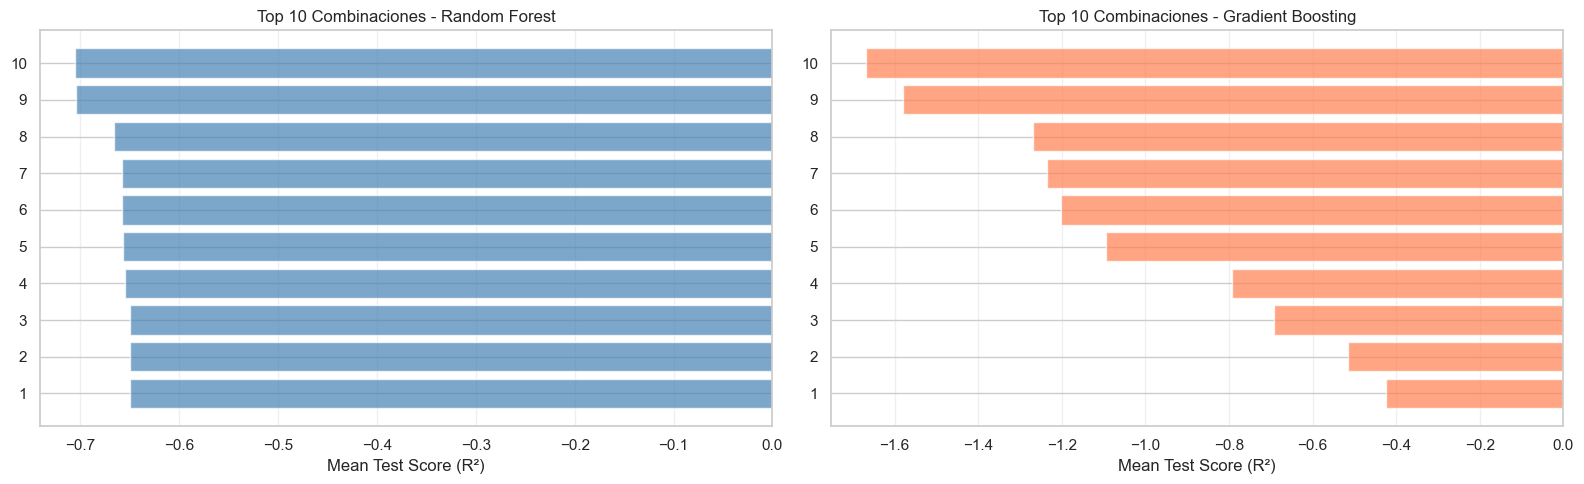

Gráfico guardado


In [6]:
# Gráfico: Evolución del score en Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Random Forest - Top parámetros
cv_results_rf = resultados_rf['cv_results'].sort_values('rank_test_score').head(10)
axes[0].barh(range(len(cv_results_rf)), cv_results_rf['mean_test_score'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(cv_results_rf)))
axes[0].set_yticklabels([f"{i+1}" for i in range(len(cv_results_rf))])
axes[0].set_xlabel('Mean Test Score (R²)')
axes[0].set_title('Top 10 Combinaciones - Random Forest')
axes[0].grid(alpha=0.3, axis='x')

# Gradient Boosting - Top parámetros
cv_results_gb = resultados_gb['cv_results'].sort_values('rank_test_score').head(10)
axes[1].barh(range(len(cv_results_gb)), cv_results_gb['mean_test_score'].values, color='coral', alpha=0.7)
axes[1].set_yticks(range(len(cv_results_gb)))
axes[1].set_yticklabels([f"{i+1}" for i in range(len(cv_results_gb))])
axes[1].set_xlabel('Mean Test Score (R²)')
axes[1].set_title('Top 10 Combinaciones - Gradient Boosting')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'results/plots/08_optimizacion_hiperparametros.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Gráfico guardado")

## 6. Reporte de Optimización

In [7]:
# Crear reporte
crear_reporte_optimizacion(resultados_rf, resultados_gb, 
                           os.path.join(project_root, 'results/reports/04_optimizacion.txt'))

# Guardar resultados CV
ruta_cv_rf = os.path.join(project_root, 'results/metrics/04_cv_results_rf.csv')
ruta_cv_gb = os.path.join(project_root, 'results/metrics/04_cv_results_gb.csv')

resultados_rf['cv_results'].to_csv(ruta_cv_rf, index=False)
resultados_gb['cv_results'].to_csv(ruta_cv_gb, index=False)

print(f"Resultados CV guardados")
print(f"  Random Forest: {ruta_cv_rf}")
print(f"  Gradient Boosting: {ruta_cv_gb}")

print("\n✓ Optimización completada exitosamente")

Reporte guardado en: C:\Users\Arturo\Desktop\Prueba1\results/reports/04_optimizacion.txt
Resultados CV guardados
  Random Forest: C:\Users\Arturo\Desktop\Prueba1\results/metrics/04_cv_results_rf.csv
  Gradient Boosting: C:\Users\Arturo\Desktop\Prueba1\results/metrics/04_cv_results_gb.csv

✓ Optimización completada exitosamente
